# 1d Filter Implementation
A kalman filter keeps track of the estimated state of the system and the variance or uncertainty of the estimate. <a href="https://en.wikipedia.org/wiki/Kalman_filter">(wikipedia)</a>

We have a system motion model w/ constant velocity $s$, moving along a 1d line.
$$
x_{t} = x_{t-1} + s + n_{p}
$$
with gaussian process noise $n_{p}$
$$
n_{p} \sim N(0, \sigma_{p})
$$

Predictions then update through the recursive motion equations
$$
\hat{x} \rightarrow \hat{x} + s
$$
Variance compounds each timestep due to process noise
$$
\sigma^{2} \rightarrow \sigma^{2} + \sigma_{p}^{2}
$$
$$
v \rightarrow v + \sigma_{p}^{2}
$$

We also must take into account that we have noise in the measurement apparatus. Therefore we have our measurement z which is the ground truth position with gaussian measurement noise added
$$
z = x + n_{m}
$$
Where again, this is gaussian noise...
$$
n_{m} \sim N(0, \sigma_{m})
$$

From a long draw out derivation, we know that our predictions of the mean and variance must update like so
$$
\hat{x} = \hat{x} + K(z - \hat{x})
$$

$$
\sigma^{2} = \sigma^{2} - K \sigma^{2}
$$

And here, we know that K is our "kalman gain"
$$
K = \frac{v}{v + \sigma^2_{m}}
$$

### Real Trajectory Simulation
First, we should just simulate the real trajectory

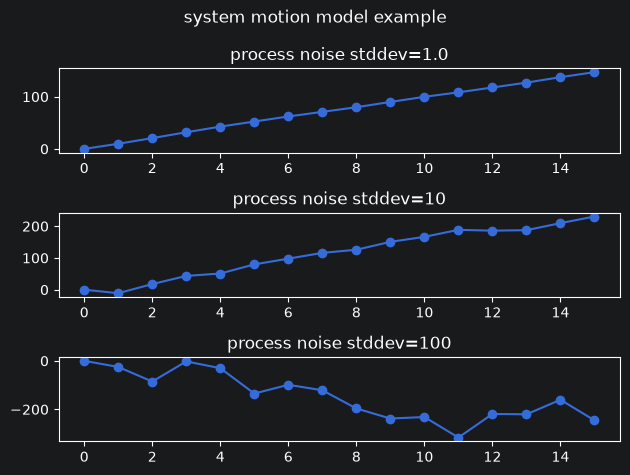

In [130]:
import numpy as np
from matplotlib import pyplot as plt
plt.close('all')

def system_step(n, x_vec, s, sigma_p):
    if n <= 0:
        return x_vec
    process_noise = np.random.normal(0, sigma_p)
    x = x_vec[-1] + s + process_noise
    x_vec.append(x)
    return system_step(n - 1, x_vec, s, sigma_p)

fig, axs = plt.subplots(3)
s = 10.0
for i,sigma_p in enumerate([1.0, 10, 100]):
    x_vec = [0]
    real_traj = system_step(15, x_vec, s, sigma_p)
    axs[i].plot(real_traj, linestyle='-', marker='o')
    axs[i].set_title(f"process noise stddev={sigma_p}")
fig.suptitle("system motion model example")
plt.tight_layout()

## Add measurement noise

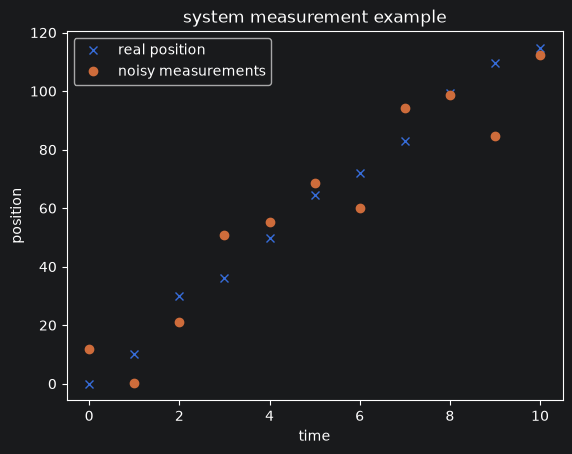

In [131]:
def make_measurements(real_traj, sigma_m):
    measure_noise = np.random.normal(0, sigma_m, len(real_traj))
    noisy_traj = [
        t + m for t,m in zip(real_traj, measure_noise)
    ]
    return noisy_traj

s = 10.0
sigma_p = 5.0
x_vec = [0]
n = 10
real_traj = system_step(n, x_vec, s, sigma_p)
sigma_m = 10.0
measured_traj = make_measurements(real_traj, sigma_m)
plt.plot(real_traj, linestyle='', marker='x', label="real position")
plt.plot(measured_traj, linestyle='', marker='o', label="noisy measurements")
plt.title("system measurement example")
plt.xlabel("time")
plt.ylabel("position")
plt.legend()

## Now we implement kalman step
From a long draw out derivation in the <a href="https://github.com/cravies/BayesianTracking/blob/main/16.3_Kalman_Filtering.pdf">slides</a>) (which mixed up q and r notation!), we know that our predictions of the mean and the variance in the state prediction must update like so
$$
\hat{x} = \hat{x} + K(z - \hat{x})
$$

$$
v = (1 - K) * v
$$

And here, we again know that K is our "kalman gain"
$$
K = \frac{v}{v + \sigma_{m}^{2}}
$$

So how do we translate this into a function we can recursively step?
Let's ask ourselves - what do we know?
We know x (this is just recursively updated $x_{0}$ - just set this to our first measurement...)
We know z - it's our recieved measurement!
We know process and measurement variance... (physical calibration)

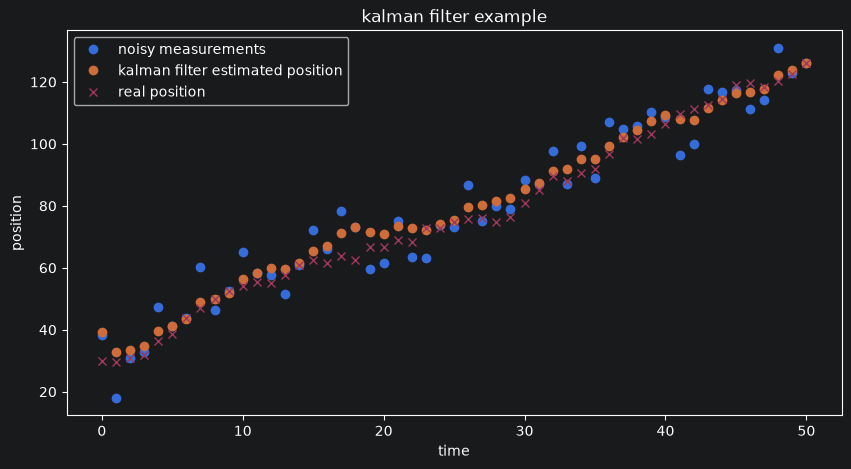

In [140]:
def kalman_step(x, z, s, var, process_var, measurement_var):
    x = x + s
    var = var + process_var
    # how much should we trust
    K = var / (var + measurement_var)
    x = x + K*(z - x)
    var = (1 - K) * var
    return x, var, K

s = 2.0
sigma_p = 2.0
x_vec = [30]
n = 50
real_traj = system_step(n, x_vec, s, sigma_p)
sigma_m = 8.0
measured_traj = make_measurements(real_traj, sigma_m)

process_var = sigma_p ** 2
measurement_var = sigma_m ** 2
var = measurement_var
mean_traj = []
var_traj = []
K_traj = []
x = measured_traj[0]
for i,z in enumerate(measured_traj):
    # filter as we go
    x, var, K = kalman_step(
        x, z, s, var, process_var, measurement_var
    )
    mean_traj.append(x)
    var_traj.append(var)
    K_traj.append(K)

plt.figure(figsize=(10, 5))
plt.plot(measured_traj, linestyle='', marker='o', label="noisy measurements")
plt.plot(mean_traj, linestyle='', marker='o', label="kalman filter estimated position")
plt.plot(real_traj, linestyle='', marker='x', label="real position")
plt.title("kalman filter example")
plt.xlabel("time")
plt.ylabel("position")
plt.legend()

## Interpretation
The K ratio determines the balance between trusting the sensor and trusting the motion model prediction.
Every iteration, process noise makes the variance larger, and measurement information reduces the variance. (smaller measurement noise results in a bigger variance reduction).
Eventually, this converges and $v$ stays fixed. For this problem, we then have our optimal K, we can hardcode it in production.

Text(0, 0.5, 'kalman filter estimated variance')

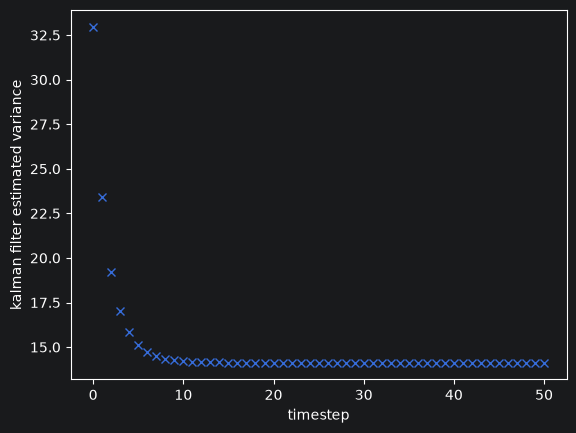

In [141]:
plt.plot(var_traj, linestyle='', marker='x')
plt.xlabel("timestep")
plt.ylabel("kalman filter estimated variance")

Text(0, 0.5, 'kalman filter gain')

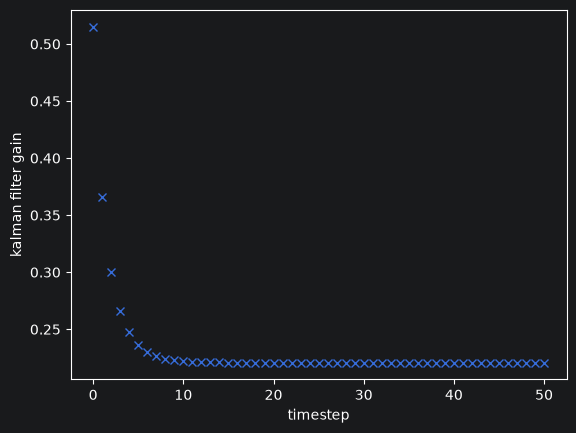

In [142]:
plt.plot(K_traj, linestyle='', marker='x')
plt.xlabel("timestep")
plt.ylabel("kalman filter gain")